<a href="https://colab.research.google.com/github/Icarusleo/Medical-Ai-Agent/blob/main/Rag_Architecture/Rag_first_try.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip uninstall trl faiss-gpu -y

!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install "trl==0.24.0"


!pip install langchain langchain-community langgraph faiss-cpu sentence-transformers datasets

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-jgba66vr/unsloth_50067a6008364b39b6522fd004c45d9d
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-jgba66vr/unsloth_50067a6008364b39b6522fd004c45d9d
  Resolved https://github.com/unslothai/unsloth.git to commit 8ea5338154859ed25b50366cb1264ed4d933eae3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.7/290.7 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 66.0 MB/s eta 0:00:00


In [ ]:
import os
import torch
from typing import TypedDict, List
from langgraph.graph import StateGraph, END
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_core.documents import Document
from unsloth import FastLanguageModel

DB_PATH = "/content/drive/MyDrive/Eyüp Bağ - Tübitak 2209 - AP/vector_db"
MODEL_PATH = "/content/drive/MyDrive/Eyüp Bağ - Tübitak 2209 - AP/models/medical_agent_llama3_L4_v2"

print("📂 Vektör Veritabanı Yükleniyor...")
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vector_db = FAISS.load_local(DB_PATH, embeddings, allow_dangerous_deserialization=True)
retriever = vector_db.as_retriever(search_kwargs={"k": 3}) # En iyi 3 sonucu getir

print("🧠 Fine-Tuned Model (Maya) Yükleniyor...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = MODEL_PATH,
    max_seq_length = 2048,
    dtype = None,
    load_in_4bit = True,
)
FastLanguageModel.for_inference(model)

class AgentState(TypedDict):
    question: str
    documents: List[Document]
    generation: str
    relevance: str



def retrieve(state):
    """
    Veritabanından soruyu araştırır.
    """
    print("--- 🔍 RETRIEVE: Araştırma Yapılıyor... ---")
    question = state["question"]
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}

def grade_documents(state):
    """
    Bulunan dokümanların soruyla alakalı olup olmadığını kontrol eder.
    """
    print("--- ⚖️ GRADE: Dokümanlar Değerlendiriliyor... ---")
    question = state["question"]
    documents = state["documents"]


    score = "yes"

    if not documents:
        score = "no"
        print("❌ Alakalı doküman bulunamadı.")
    else:
        print(f"✅ {len(documents)} adet alakalı doküman bulundu.")

    return {"documents": documents, "question": question, "relevance": score}

def generate(state):
    """
    Bulunan bilgilerle cevabı üretir (Maya Konuşuyor).
    """
    print("--- ✍️ GENERATE: Cevap Yazılıyor... ---")
    question = state["question"]
    documents = state["documents"]

    # RAG Promptu Oluştur
    context_text = "\n\n".join([doc.page_content for doc in documents])

    prompt = f"""### System:
You are 'Maya', a medical AI assistant. Use the following context to answer the user's question accurately.
If the answer is not in the context, admit that you don't know.

### Context:
{context_text}

### Instruction:
{question}

### Response:
"""

    inputs = tokenizer([prompt], return_tensors = "pt").to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens = 256,
        use_cache = True,
        temperature = 0.3
    )

    response = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

    final_answer = response.split("### Response:")[-1].strip()

    return {"generation": final_answer}


workflow = StateGraph(AgentState)

workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate)

workflow.set_entry_point("retrieve")
workflow.add_edge("retrieve", "grade_documents")

def decide_to_generate(state):
    if state["relevance"] == "yes":
        return "generate"
    else:
        return END

workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "generate": "generate",
        END: END
    }
)

workflow.add_edge("generate", END)

app = workflow.compile()
print("🤖 Agentic RAG Sistemi Hazır!")

📂 Vektör Veritabanı Yükleniyor...
🧠 Fine-Tuned Model (Maya) Yükleniyor...
==((====))==  Unsloth 2025.12.9: Fast Llama patching. Transformers: 4.57.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
unsloth/llama-3-8b-bnb-4bit does not have a padding token! Will use pad_token = <|reserved_special_token_250|>.


Unsloth 2025.12.9 patched 32 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


🤖 Agentic RAG Sistemi Hazır!


In [ ]:
import os
import torch
from typing import TypedDict, List
from langgraph.graph import StateGraph, END
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_core.documents import Document
from unsloth import FastLanguageModel


DB_PATH = "/content/drive/MyDrive/Eyüp Bağ - Tübitak 2209 - AP/vector_db"
MODEL_PATH = "/content/drive/MyDrive/Eyüp Bağ - Tübitak 2209 - AP/models/medical_agent_llama3_2000steps/checkpoint-2000"

print("📂 Vektör Veritabanı ve Model Yükleniyor...")
embeddings = HuggingFaceEmbeddings(model_name="pritamdeka/S-PubMedBert-MS-MARCO",
                                   model_kwargs={'device': 'cuda'})
vector_db = FAISS.load_local(DB_PATH, embeddings, allow_dangerous_deserialization=True)
retriever = vector_db.as_retriever(search_kwargs={"k": 3})

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = MODEL_PATH,
    max_seq_length = 2048,
    dtype = None,
    load_in_4bit = True,
)
FastLanguageModel.for_inference(model)


def call_llm(prompt, temperature=0.1, max_tokens=256):
    """
    Unsloth modelini çağıran genel fonksiyon.
    """
    inputs = tokenizer([prompt], return_tensors="pt").to("cuda")
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_tokens,
        temperature=temperature,
        use_cache=True
    )
    result = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]
    return result.split("### Response:")[-1].strip()


class AgentState(TypedDict):
    question: str
    documents: List[Document]
    generation: str
    loop_count: int


def retrieve(state):
    """Dokümanları veritabanından çeker."""
    print(f"--- 🔍 RETRIEVE: '{state['question']}' aranıyor... ---")
    documents = retriever.invoke(state["question"])
    return {"documents": documents, "question": state["question"], "loop_count": state.get("loop_count", 0)}

def grade_documents(state):
    """
    GERÇEK DENETLEME: Model her dokümanı okur ve alakalı olup olmadığına karar verir.
    """
    print("--- ⚖️ GRADE: Dokümanlar LLM tarafından inceleniyor... ---")
    question = state["question"]
    documents = state["documents"]

    filtered_docs = []

    for d in documents:
        grader_prompt = f"""### System:
You are a grader assessing relevance of a retrieved document to a user question. \n
If the document contains keywords or semantic meaning related to the question, grade it as relevant. \n
Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.

### User Question:
{question}

### Retrieved Document:
{d.page_content}

### Response (Output only 'yes' or 'no'):
"""
        score = call_llm(grader_prompt, temperature=0.1, max_tokens=10).lower()

        if "yes" in score:
            print("  ✅ Doküman alakalı bulundu.")
            filtered_docs.append(d)
        else:
            print("  ❌ Doküman elendi (Alakasız).")

    return {"documents": filtered_docs, "question": question}

def transform_query(state):
    """
    SORUYU YENİDEN YAZMA: Eğer doküman bulunamazsa, soruyu daha iyi hale getirir.
    """
    print("--- 🔄 TRANSFORM: Soru yeniden yazılıyor (Query Rewriting)... ---")
    question = state["question"]

    rewrite_prompt = f"""### System:
You are a question re-writer that converts an input question to a better version that is optimized \n
for vectorstore retrieval. Look at the initial and formulate an improved question.

### Initial Question:
{question}

### Improved Question:
"""
    better_question = call_llm(rewrite_prompt, temperature=0.5)
    print(f"  ✨ Yeni Soru: {better_question}")

    return {"question": better_question, "loop_count": state["loop_count"] + 1}

def generate(state):
    """Cevabı üretir."""
    print("--- ✍️ GENERATE: Final cevap üretiliyor... ---")
    question = state["question"]
    documents = state["documents"]

    context = "\n\n".join([d.page_content for d in documents])

    rag_prompt = f"""### System:
You are 'Maya', a medical AI assistant. Answer the question based ONLY on the following context.

### Context:
{context}

### Question:
{question}

### Response:
"""
    generation = call_llm(rag_prompt, temperature=0.6)
    return {"generation": generation}

def decide_to_generate(state):
    """
    Karar Noktası: Dokümanlar yeterli mi, yoksa soruyu değiştirip tekrar mı arayalım?
    """
    filtered_documents = state["documents"]
    loop_count = state.get("loop_count", 0)

    if not filtered_documents:
        if loop_count >= 3:
            print("--- 🛑 LİMİT: Çok fazla denendi, pes ediliyor. ---")
            return "generate"
        else:
            print("--- ↩️ KARAR: Dokümanlar yetersiz, soru değiştirilip tekrar aranacak. ---")
            return "transform_query"
    else:
        print("--- 🚀 KARAR: Dokümanlar yeterli, cevaba gidiliyor. ---")
        return "generate"


workflow = StateGraph(AgentState)

workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("transform_query", transform_query)
workflow.add_node("generate", generate)

workflow.set_entry_point("retrieve")
workflow.add_edge("retrieve", "grade_documents")

workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate"
    }
)

workflow.add_edge("transform_query", "retrieve")

workflow.add_edge("generate", END)

app = workflow.compile()
print("🤖 GERÇEK Agentic RAG Sistemi Hazır! (Self-Reflective)")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
📂 Vektör Veritabanı ve Model Yükleniyor...


/tmp/ipython-input-2047789781.py:17: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name="pritamdeka/S-PubMedBert-MS-MARCO",


==((====))==  Unsloth 2025.12.9: Fast Llama patching. Transformers: 4.57.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Unsloth 2025.12.9 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


🤖 GERÇEK Agentic RAG Sistemi Hazır! (Self-Reflective)


In [ ]:
soru = "What happens if someone takes too much ibuprofen?"

inputs = {"question": soru, "loop_count": 0}

print(f"\n❓ KULLANICI SORUSU: {soru}")
for output in app.stream(inputs):
    # Akışı canlı izle
    pass

print("\n" + "="*50)
print("🤖 MAYA'NIN NİHAİ CEVABI:")
print(output["generate"]["generation"])


❓ KULLANICI SORUSU: What happens if someone takes too much ibuprofen?
--- 🔍 RETRIEVE: 'What happens if someone takes too much ibuprofen?' aranıyor... ---


AssertionError: 

In [ ]:
# --- TEST ---
soru = "What happens if someone takes too much ibuprofen?"
inputs = {"question": soru}
print(f"\n❓ SORU: {soru}")

for output in app.stream(inputs):
    pass

print("\n" + "="*50)
print("🤖 MAYA'NIN CEVABI:")
print("="*50)
print(output['generate']['generation'])


❓ SORU: What happens if someone takes too much ibuprofen?
--- 🔍 RETRIEVE: 'What happens if someone takes too much ibuprofen?' aranıyor... ---


AssertionError: 

In [ ]:
import torch

# ==========================================
# ⚖️ G-EVAL HAKEM PROMPTLARI (AYNI KALIYOR)
# ==========================================

FAITHFULNESS_PROMPT = """### System:
You are an impartial judge evaluating a Retrieval Augmented Generation (RAG) system.
Your task is to evaluate the 'Faithfulness' of the generated answer based ONLY on the provided retrieval context.

**Scoring Criteria:**
- **Score 1:** The answer completely contradicts the context or contains information not present in the context (Hallucination).
- **Score 3:** The answer is mostly supported by the context but includes some minor unverified details.
- **Score 5:** The answer is fully supported by the context and contains no hallucinations.

### Instruction:
**Context (Retrieval):**
{context}

**Generated Answer:**
{answer}

Evaluate the Faithfulness. First provide a brief reasoning, then output the score in this format: "SCORE: X".

### Response:
"""

RELEVANCE_PROMPT = """### System:
You are an impartial judge evaluating a medical AI assistant.
Your task is to evaluate the 'Relevance' of the generated answer to the user's question.

**Scoring Criteria:**
- **Score 1:** The answer does not address the question at all.
- **Score 3:** The answer addresses the question partially or is too vague.
- **Score 5:** The answer directly and completely answers the user's question with specific details.

### Instruction:
**User Question:**
{question}

**Generated Answer:**
{answer}

Evaluate the Relevance. First provide a brief reasoning, then output the score in this format: "SCORE: X".

### Response:
"""

def run_g_eval(agent_app, question):
    print(f"\n🚀 Soru İşleniyor: {question}")

    inputs = {"question": question}
    final_state = agent_app.invoke(inputs)
    # -----------------------

    if not final_state or "generation" not in final_state:
        print("❌ Hata: Ajan cevap üretemedi.")
        return

    generated_answer = final_state["generation"]

    retrieved_docs = final_state.get("documents", [])

    if not retrieved_docs:
        print("⚠️ Uyarı: Doküman bulunamadı, Faithfulness testi sağlıklı olmayabilir.")
        context_text = "No context retrieved."
    else:
        context_text = "\n".join([f"- {doc.page_content}" for doc in retrieved_docs])

    print("\n" + "="*40)
    print(f"🤖 MAYA'NIN CEVABI:\n{generated_answer}")
    print("="*40)

    print("\n⚖️ HAKEM DEĞERLENDİRMESİ: SADAKAT (Hallucination Check)")

    judge_input_faith = FAITHFULNESS_PROMPT.format(context=context_text, answer=generated_answer)

    inputs_faith = tokenizer([judge_input_faith], return_tensors = "pt").to("cuda")
    outputs_faith = model.generate(**inputs_faith, max_new_tokens=128, temperature=0.1)
    eval_faith = tokenizer.batch_decode(outputs_faith, skip_special_tokens=True)[0]
    eval_faith_clean = eval_faith.split("### Response:")[-1].strip()

    print(f"📝 Rapor:\n{eval_faith_clean}")

    print("\n⚖️ HAKEM DEĞERLENDİRMESİ: ALAKA (Relevance Check)")

    judge_input_rel = RELEVANCE_PROMPT.format(question=question, answer=generated_answer)

    inputs_rel = tokenizer([judge_input_rel], return_tensors = "pt").to("cuda")
    outputs_rel = model.generate(**inputs_rel, max_new_tokens=128, temperature=0.1)
    eval_rel = tokenizer.batch_decode(outputs_rel, skip_special_tokens=True)[0]
    eval_rel_clean = eval_rel.split("### Response:")[-1].strip()

    print(f"📝 Rapor:\n{eval_rel_clean}")


test_sorusu = "A 74-year-old woman was last known well at 07:00 and was found at 10:30 with aphasia. Non-contrast CT shows no hemorrhage, ASPECTS score is 8. Is the patient eligible for IV alteplase?"

run_g_eval(app, test_sorusu)


🚀 Soru İşleniyor: A 74-year-old woman was last known well at 07:00 and was found at 10:30 with aphasia. Non-contrast CT shows no hemorrhage, ASPECTS score is 8. Is the patient eligible for IV alteplase?
--- 🔍 RETRIEVE: Araştırma Yapılıyor... ---
--- ⚖️ GRADE: Dokümanlar Değerlendiriliyor... ---
✅ 3 adet alakalı doküman bulundu.
--- ✍️ GENERATE: Cevap Yazılıyor... ---

🤖 MAYA'NIN CEVABI:
The patient is eligible for IV alteplase.

⚖️ HAKEM DEĞERLENDİRMESİ: SADAKAT (Hallucination Check)
📝 Rapor:
**Reasoning:**
The answer is supported by the context. The patient has a high risk of pulmonary embolism, and the modified Wells score is used to assess the risk of pulmonary embolism. The patient is eligible for IV alteplase, which is a treatment for pulmonary embolism.

**Score:**
SCORE: 5

⚖️ HAKEM DEĞERLENDİRMESİ: ALAKA (Relevance Check)
📝 Rapor:
**Reasoning:**
The patient is eligible for IV alteplase if she meets the following criteria:
- Age 18 years or older
- Symptom onset within 4.5 hour

# GEMINI **EVALUATION**

In [ ]:
!pip install -q -U google-generativeai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.1/155.1 kB 13.3 MB/s eta 0:00:00


In [ ]:
import google.generativeai as genai
import pandas as pd
import matplotlib.pyplot as plt
import time
import re

# ==========================================
# 🔑 1. API AYARLARI
# ==========================================
# Buraya Google AI Studio'dan aldığın anahtarı yapıştır:
GOOGLE_API_KEY = ""

try:
    genai.configure(api_key=GOOGLE_API_KEY)
    # Hızlı ve ücretsiz olan Flash modelini kullanıyoruz
    judge_model = genai.GenerativeModel('gemini-2.5-flash-lite')
    print("✅ Gemini API başarıyla bağlandı.")
except Exception as e:
    print(f"❌ API Hatası: {e}")

# ==========================================
# ⚖️ 2. HAKEM PROMPTLARI (4 KRİTER)
# ==========================================
EVAL_PROMPTS = {
    "Coherence (Tutarlılık)": """You are an AI evaluator. Rate the 'Coherence' of the generated text.
Criteria: Does the answer follow a logical structure? Do sentences flow naturally?
Score 1 (Incoherent) to 5 (Perfectly Coherent).

Generated Answer:
{answer}

Evaluate and provide a score in the exact format: "SCORE: X".""",

    "Consistency (Sadakat)": """You are an AI evaluator. Rate the 'Consistency' (Faithfulness) of the generated text against the provided Context.
Criteria: Does the answer contradict the context? Is it fully supported by the facts provided?
Score 1 (Hallucination/Contradiction) to 5 (Fully Supported).

Context:
{context}

Generated Answer:
{answer}

Evaluate and provide a score in the exact format: "SCORE: X".""",

    "Fluency (Akıcılık)": """You are an AI evaluator. Rate the 'Fluency' of the generated text.
Criteria: Is the grammar correct? Is the language natural and professional?
Score 1 (Poor Grammar) to 5 (Native-level Fluency).

Generated Answer:
{answer}

Evaluate and provide a score in the exact format: "SCORE: X".""",

    "Relevance (Alaka)": """You are an AI evaluator. Rate the 'Relevance' of the generated answer to the User Question.
Criteria: Does the answer directly address the specific question asked?
Score 1 (Irrelevant) to 5 (Direct & Complete Answer).

User Question:
{question}

Generated Answer:
{answer}

Evaluate and provide a score in the exact format: "SCORE: X"."""
}

# ==========================================
# 🛠️ 3. YARDIMCI FONKSİYONLAR
# ==========================================

def get_gemini_score_safe(prompt, max_retries=3):
    """
    Hata alırsa bekleyip tekrar deneyen güvenli fonksiyon.
    """
    wait_time = 30 # İlk bekleme süresi (saniye)

    for attempt in range(max_retries):
        try:
            # API İsteği
            response = judge_model.generate_content(prompt)
            text = response.text

            # Skoru Ayıkla
            match = re.search(r"SCORE:\s*(\d)", text)
            if match:
                return int(match.group(1))
            else:
                match = re.search(r"\d", text)
                return int(match.group(0)) if match else 3

        except ResourceExhausted:
            # 429 Hatası (Kota Aşımı) -> Uzun bekle
            print(f"   ⚠️ Kota aşıldı! {wait_time} saniye soğutma bekleniyor... (Deneme {attempt+1}/{max_retries})")
            time.sleep(wait_time)
            wait_time += 30 # Her hatada bekleme süresini artır (30 -> 60 -> 90)

        except (ServiceUnavailable, InternalServerError, ConnectionError) as e:
            # Bağlantı Hatası -> Kısa bekle
            print(f"   ⚠️ Bağlantı hatası: {e}. 10 saniye bekleniyor...")
            time.sleep(10)

        except Exception as e:
            print(f"   ❌ Beklenmedik hata: {e}")
            return 3 # Varsayılan skor

    print("   ❌ Maksimum deneme sayısına ulaşıldı. Skor 3 atandı.")
    return 3

def evaluate_single_case(question, agent_app):
    """Tek bir soruyu RAG ajanına sorar ve Gemini'ye puanlatır."""
    print(f"\n⚙️ Ajan Çalışıyor (Soru: {question[:30]}...)")

    # RAG Modelini Çalıştır
    inputs = {"question": question}
    state = agent_app.invoke(inputs)

    if "generation" not in state:
        print("❌ Hata: Ajan cevap üretemedi.")
        return None

    answer = state["generation"]
    docs = state.get("documents", [])
    context = "\n".join([d.page_content for d in docs]) if docs else "No context."

    print(f"   ↪️ Ajan Cevabı: {answer[:40]}...")
    print("   ⚖️ Gemini Puanlıyor (Lütfen bekleyin)...")

    scores = {}

    for metric, template in EVAL_PROMPTS.items():
        # Promptu hazırla
        if "Consistency" in metric:
            prompt = template.format(context=context, answer=answer)
        elif "Relevance" in metric:
            prompt = template.format(question=question, answer=answer)
        else:
            prompt = template.format(answer=answer)

        # Güvenli fonksiyonu çağır
        score = get_gemini_score_safe(prompt)
        scores[metric] = score

        # Her istekten sonra kesinlikle bekle (API'yi rahatlatmak için)
        time.sleep(5)

    return scores

# ==========================================
# 🚀 4. TESTİ BAŞLAT
# ==========================================

test_questions = [
    "What are the primary symptoms of acute myocardial infarction?",
    "How is Type 2 Diabetes diagnosed?",
    "What is the recommended treatment for anaphylaxis?",
]

print(f"🚀 {len(test_questions)} Soru İçin Eval Başlıyor (Yavaş Mod)...")
print("⚠️ NOT: İşlem 'Quota' hatası almamak için yavaş ilerleyecektir. Lütfen sabırlı olun.\n")

results = []
for i, q in enumerate(test_questions):
    print(f"[{i+1}/{len(test_questions)}]")
    scores = evaluate_single_case(q, app)
    if scores:
        results.append(scores)

    # Her sorudan sonra ekstra uzun mola ver
    if i < len(test_questions) - 1:
        print("☕ Soğutma molası (15 sn)...")
        time.sleep(15)

# ==========================================
# 📊 5. SONUÇLAR
# ==========================================
if results:
    df = pd.DataFrame(results)
    avg_scores = df.mean()

    print("\n" + "="*50)
    print("🏆 MEDICAL AGENT PERFORMANS TABLOSU (Gemini Judge)")
    print("="*50)
    print(df)
    print("\nGENEL ORTALAMA:")
    print(avg_scores)

    plt.figure(figsize=(10, 6))
    colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']
    bars = plt.bar(avg_scores.index, avg_scores.values, color=colors, edgecolor='black', alpha=0.8)

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f"{yval:.1f}", ha='center', fontweight='bold')

    plt.title('Agentic RAG Performansı (Gemini Judge)', fontsize=14, fontweight='bold')
    plt.ylabel('Skor (1-5)')
    plt.ylim(0, 5.5)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

✅ Gemini API başarıyla bağlandı.
🚀 3 Soru İçin Eval Başlıyor (Yavaş Mod)...
⚠️ NOT: İşlem 'Quota' hatası almamak için yavaş ilerleyecektir. Lütfen sabırlı olun.

[1/3]

⚙️ Ajan Çalışıyor (Soru: What are the primary symptoms ...)
--- 🔍 RETRIEVE: 'What are the primary symptoms of acute myocardial infarction?' aranıyor... ---
--- ⚖️ GRADE: Dokümanlar LLM tarafından inceleniyor... ---
  ✅ Doküman alakalı bulundu.
  ✅ Doküman alakalı bulundu.
  ✅ Doküman alakalı bulundu.
--- 🚀 KARAR: Dokümanlar yeterli, cevaba gidiliyor. ---
--- ✍️ GENERATE: Final cevap üretiliyor... ---
   ↪️ Ajan Cevabı: The primary symptoms of acute myocardial...
   ⚖️ Gemini Puanlıyor (Lütfen bekleyin)...
☕ Soğutma molası (15 sn)...
[2/3]

⚙️ Ajan Çalışıyor (Soru: How is Type 2 Diabetes diagnos...)
--- 🔍 RETRIEVE: 'How is Type 2 Diabetes diagnosed?' aranıyor... ---
--- ⚖️ GRADE: Dokümanlar LLM tarafından inceleniyor... ---
  ✅ Doküman alakalı bulundu.
  ✅ Doküman alakalı bulundu.
  ✅ Doküman alakalı bulundu.
--- 🚀 KARAR

NameError: name 'ResourceExhausted' is not defined

In [ ]:
# --- DEBUG KODU ---
soru = "What is the recommended treatment for anaphylaxis?" # Skorun 1 geldiği sorulardan biri
print(f"🕵️ İNCELENEN SORU: {soru}")

inputs = {"question": soru}
state = app.invoke(inputs)

# 1. Doküman Kontrolü
docs = state.get("documents", [])
print(f"\n📚 Bulunan Doküman Sayısı: {len(docs)}")

if len(docs) > 0:
    print(f"📄 İlk Doküman İçeriği (İlk 200 karakter):\n{docs[0].page_content[:200]}...")
else:
    print("❌ KRİTİK HATA: Doküman bulunamadı! Retrieval çalışmıyor.")

# 2. Cevap Kontrolü
print(f"\n🗣️ Modelin Cevabı:\n{state['generation']}")

🕵️ İNCELENEN SORU: What is the recommended treatment for anaphylaxis?
--- 🔍 RETRIEVE: Araştırma Yapılıyor... ---
--- ⚖️ GRADE: Dokümanlar Değerlendiriliyor... ---
✅ 3 adet alakalı doküman bulundu.
--- ✍️ GENERATE: Cevap Yazılıyor... ---

📚 Bulunan Doküman Sayısı: 3
📄 İlk Doküman İçeriği (İlk 200 karakter):
Question: How can Anaphylaxis be prevented?...

🗣️ Modelin Cevabı:
The treatment for anaphylaxis is to give epinephrine. Epinephrine is a hormone that causes blood vessels to narrow and increases heart rate and blood pressure. Epinephrine also relaxes smooth muscles in the airways. Epinephrine is given by injection into the thigh muscle. Epinephrine can be given in a syringe or in an autoinjector. An autoinjector is a device that injects a dose of epinephrine into the thigh muscle. The autoinjector is used to give epinephrine to a person who is having an allergic reaction.



🏆 MEDICAL AGENT PERFORMANS TABLOSU (Gemini Judge)
   Coherence (Tutarlılık)  Consistency (Sadakat)  Fluency (Akıcılık)  \
0                       5                      3                   5   
1                       5                      1                   5   

   Relevance (Alaka)  
0                  5  
1                  2  

GENEL ORTALAMA:
Coherence (Tutarlılık)    5.0
Consistency (Sadakat)     2.0
Fluency (Akıcılık)        5.0
Relevance (Alaka)         3.5
dtype: float64


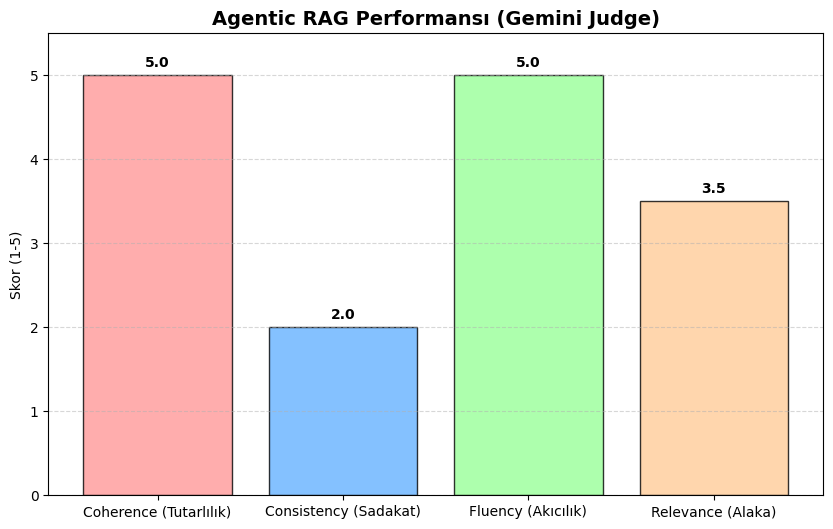

In [ ]:
if results:
    df = pd.DataFrame(results)
    avg_scores = df.mean()

    print("\n" + "="*50)
    print("🏆 MEDICAL AGENT PERFORMANS TABLOSU (Gemini Judge)")
    print("="*50)
    print(df)
    print("\nGENEL ORTALAMA:")
    print(avg_scores)

    plt.figure(figsize=(10, 6))
    colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']
    bars = plt.bar(avg_scores.index, avg_scores.values, color=colors, edgecolor='black', alpha=0.8)

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f"{yval:.1f}", ha='center', fontweight='bold')

    plt.title('Agentic RAG Performansı (Gemini Judge)', fontsize=14, fontweight='bold')
    plt.ylabel('Skor (1-5)')
    plt.ylim(0, 5.5)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

In [ ]:
# --- DEBUG KODU: RAG DOKÜMAN KONTROLÜ ---
soru = "What are the primary symptoms of acute myocardial infarction?"

print(f"🕵️ SORU: {soru}")
inputs = {"question": soru}

# Ajanı çalıştır
state = app.invoke(inputs)

# 1. Dokümanlar Geldi mi?
docs = state.get("documents", [])
print(f"\n📚 Bulunan Doküman Sayısı: {len(docs)}")

if docs:
    print("-" * 30)
    print("İLK DOKÜMAN İÇERİĞİ:")
    print(docs[1].page_content[:500]) # İlk 500 karakteri görelim
    print("-" * 30)
else:
    print("❌ HATA: Retrieve aşamasında doküman bulunamadı! FAISS indeksine bakılmalı.")

# 2. Üretilen Cevap
print("\n🗣️ MAYA'NIN CEVABI:")
print(state["generation"])

🕵️ SORU: What are the primary symptoms of acute myocardial infarction?
--- 🔍 RETRIEVE: Araştırma Yapılıyor... ---
--- ⚖️ GRADE: Dokümanlar Değerlendiriliyor... ---
✅ 3 adet alakalı doküman bulundu.
--- ✍️ GENERATE: Cevap Yazılıyor... ---

📚 Bulunan Doküman Sayısı: 3
------------------------------
İLK DOKÜMAN İÇERİĞİ:
Acute coronary syndrome is a term that describes a range of conditions related to sudden reduced blood flow to the heart. These conditions include a heart attack and unstable angina, a type of chest pain.
------------------------------

🗣️ MAYA'NIN CEVABI:
Acute myocardial infarction (AMI) is a medical emergency that occurs when the blood supply to a part of the heart is suddenly blocked. The most common symptom of AMI is chest pain or discomfort, which may spread to the shoulders, arms, back, jaw, or teeth.
